# PlayStore-NLP-Sentiment-Analysis

Codigo Creado por: Johan Felipe Cuellar Gonzalez

DataSet Extraido de: https://www.kaggle.com/datasets/prakharrathi25/google-play-store-reviews



# Fase 0: Ingesta de Datos
Antes de aplicar técnicas de Procesamiento de Lenguaje Natural (NLP), automatizamos la carga de nuestro dataset. Para garantizar que este proyecto sea 100% reproducible por cualquier evaluador, utilizamos `gdown` para descargar las reseñas directamente desde un repositorio en la nube de forma transparente, cargándolas en un DataFrame de Pandas listo para su análisis.

In [3]:
import pandas as pd
import gdown
import os

# 1. El ID público de tu archivo en Google Drive
file_id = '11zUKt0e3jPcZFW5iG8jEPSHMpL28FPff'

# 2. Construir la URL de descarga directa
url = f'https://drive.google.com/uc?id={file_id}'
output_path = 'reviews.csv'

# 3. Descargar el archivo de forma invisible para el usuario
if not os.path.exists(output_path):
    print(" Descargando el dataset público desde la nube... (Esto solo ocurre la primera vez)")
    gdown.download(url, output_path, quiet=False)
else:
    print(" El archivo ya está descargado en este entorno.")

# 4. Cargar el dataset
df = pd.read_csv(output_path)

print(f"\n Dataset cargado exitosamente. Total de reseñas listas para analizar: {df.shape[0]}")

 El archivo ya está descargado en este entorno.

 Dataset cargado exitosamente. Total de reseñas listas para analizar: 12495


# Fase 1: Preprocesamiento de Texto (Limpieza)
El texto extraído de las reseñas crudas contiene mucho ruido (puntuación, mayúsculas, símbolos). Para que nuestro modelo analítico sea eficiente y preciso, utilizamos la librería `NLTK` para estandarizar la información. Este proceso iterativo incluye:
1. **Limpieza con Expresiones Regulares (Regex):** Eliminamos caracteres especiales y dejamos únicamente caracteres alfabéticos.
2. **Eliminación de Stop Words:** Filtramos palabras comunes que no aportan valor semántico al modelo (como "the", "and", "is").
3. **Lematización:** Reducimos las palabras a su raíz léxica (ej. transformando palabras como "charging" y "charged" a "charge"). Esto reduce drásticamente la dimensionalidad de los datos y optimiza el consumo de memoria.

In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 1. Descargar dependencias de NLTK de forma silenciosa para mantener limpia la consola
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# 2. Limpieza de estructura (Trabajando con el dataset completo)
# Eliminamos únicamente las filas que no tengan texto en la columna 'content'
df.dropna(subset=['content'], inplace=True)

# 3. Configuración de las herramientas de NLP
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# 4. Función de limpieza experta
def clean_text(text):
    if type(text) != str:
        return ""

    text = text.lower() # Convertir a minúsculas
    text = re.sub(r'[^a-z\s]', '', text) # Regex: eliminar todo lo que no sea letra o espacio

    words = text.split()
    words = [word for word in words if word not in stop_words] # Filtrar stop words
    words = [lemmatizer.lemmatize(word) for word in words] # Aplicar lematización

    return ' '.join(words)

print(f"Procesando, limpiando y lematizando {df.shape[0]} reseñas...")

# 5. Aplicar la función creando una nueva columna para preservar el dato original
df['clean_content'] = df['content'].apply(clean_text)

print("Fase 1 Completada. Comparativa de resultados:\n")
for i in range(2):
    print(f"Texto Original: {df['content'].iloc[i]}")
    print(f"Texto Limpio:   {df['clean_content'].iloc[i]}\n")

⏳ Procesando, limpiando y lematizando 12495 reseñas...
✅ Fase 1 Completada. Comparativa de resultados:

Texto Original: I cannot open the app anymore
Texto Limpio:   cannot open app anymore

Texto Original: I have been begging for a refund from this app for over a month and nobody is replying me
Texto Limpio:   begging refund app month nobody replying



# Fase 2: Análisis de Sentimiento Base (Lexicon-based con VADER)
Con la información ingestada y preprocesada, el siguiente paso es cuantificar la percepción del usuario. Para esta línea base utilizaremos VADER (Valence Aware Dictionary and sEntiment Reasoner), un modelo pre-entrenado de la librería NLTK optimizado para redes sociales y textos cortos.

A diferencia de otros modelos, VADER evalúa no solo la polaridad (positivo/negativo), sino también la intensidad del sentimiento basándose en la puntuación y las mayúsculas del texto original, lo cual es ideal para medir la frustración real en las reseñas de aplicaciones.

In [6]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Descargar el diccionario lexico de VADER silenciosamente
nltk.download('vader_lexicon', quiet=True)

# 2. Inicializar el analizador de sentimiento
sia = SentimentIntensityAnalyzer()

# 3. Funcion de clasificacion
def analyze_sentiment_vader(text):
    if type(text) != str:
        return pd.Series(['Neutral', 0.0])

    # polarity_scores devuelve 'pos', 'neu', 'neg' y 'compound' (compuesto)
    # El 'compound' es un valor normalizado entre -1 y 1
    scores = sia.polarity_scores(text)
    compound = scores['compound']

    # Umbrales estandar de la industria para VADER
    if compound >= 0.05:
        label = 'Positivo'
    elif compound <= -0.05:
        label = 'Negativo'
    else:
        label = 'Neutral'

    return pd.Series([label, compound])

print("Calculando polaridad de sentimiento en todo el dataset. Esto puede tardar un momento...")

# 4. Aplicar el modelo a las resenas
df[['vader_label', 'vader_score']] = df['content'].apply(analyze_sentiment_vader)

print("Analisis de sentimiento completado con exito.\n")

# 5. Visualizar la comparativa: Estrellas vs Sentimiento Real
columnas_ver = ['content', 'score', 'vader_label', 'vader_score']
print(df[columnas_ver].head(10))

Calculando polaridad de sentimiento en todo el dataset. Esto puede tardar un momento...
Analisis de sentimiento completado con exito.

                                             content  score vader_label  \
0                      I cannot open the app anymore      1     Neutral   
1  I have been begging for a refund from this app...      1     Neutral   
2  Very costly for the premium version (approx In...      1    Positivo   
3  Used to keep me organized, but all the 2020 UP...      1    Negativo   
4                                Dan Birthday Oct 28      1     Neutral   
5  It has changed how I viewed my different lists...      1     Neutral   
6  I'm only looking for a grocery list app but ev...      1     Neutral   
7  Reset my free trial, new phone I'd like to see...      1    Positivo   
8  How do to stop monthly payment because i don't...      1    Negativo   
9  I complain about not crashes and it was immedi...      1    Negativo   

   vader_score  
0       0.0000  
1    

# Fase 3: Modelado de Temas y Análisis de Disonancia Cognitiva

Saber que un usuario está insatisfecho no es suficiente para tomar decisiones de producto; es imperativo entender la causa de la fricción y auditar las métricas engañosas. En esta fase ejecutamos dos procesos analíticos clave:

1. **Extracción de N-gramas (Topic Modeling):** Aislamos las reseñas clasificadas como "Negativas" por VADER y aplicamos técnicas de extracción de bigramas utilizando `CountVectorizer` de Scikit-Learn. Al mapear estas frecuencias, el modelo agrupa automáticamente los motivos principales de queja (por ejemplo, "waste money", "update app", "customer service"), transformando texto no estructurado en métricas accionables para los equipos de producto.
2. **Evaluación de Disonancia Cognitiva (Boxplot):** Comparamos la calificación tradicional de la tienda (1 a 5 estrellas) con el análisis de sentimiento matemático (-1.0 a 1.0). Esta distribución cruzada permite identificar anomalías críticas, como usuarios que otorgan 5 estrellas pero reportan quejas severas en el texto, o reseñas de 1 estrella cargadas de sarcasmo.

Iniciando extraccion de temas principales en resenas negativas...


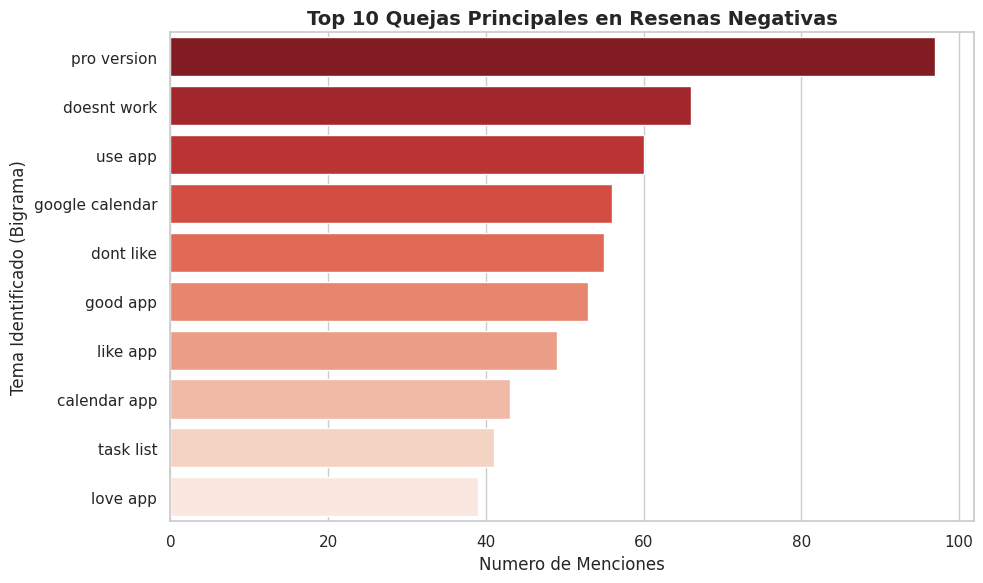

Analisis de temas completado y grafica generada.


In [10]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Iniciando extraccion de temas principales en resenas negativas...")

# 1. Filtrar el DataFrame para analizar unicamente el descontento
df_negativo = df[df['vader_label'] == 'Negativo'].copy()

# 2. Configurar el vectorizador para extraer Bigramas (pares de palabras)
# Limitamos a los 20 temas mas repetidos para mantener la relevancia
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=20)

# 3. Ajustar el modelo y transformar el texto en una matriz de frecuencias
X = vectorizer.fit_transform(df_negativo['clean_content'].fillna(''))

# 4. Consolidar los resultados en un nuevo DataFrame
frecuencias = X.sum(axis=0).A1
bigramas = vectorizer.get_feature_names_out()

df_frecuencias = pd.DataFrame({'Bigrama': bigramas, 'Frecuencia': frecuencias})
df_frecuencias = df_frecuencias.sort_values(by='Frecuencia', ascending=False)

# 5. Generar la visualizacion de impacto corporativo
plt.figure(figsize=(10, 6))
sns.barplot(x='Frecuencia', y='Bigrama', data=df_frecuencias.head(10), palette='Reds_r', hue='Bigrama', legend=False)

plt.title('Top 10 Quejas Principales en Resenas Negativas', fontsize=14, fontweight='bold')
plt.xlabel('Numero de Menciones', fontsize=12)
plt.ylabel('Tema Identificado (Bigrama)', fontsize=12)
plt.tight_layout()
plt.show()

print("Analisis de temas completado y grafica generada.")

Generando grafico de relacion: Estrellas vs Sentimiento Analitico...


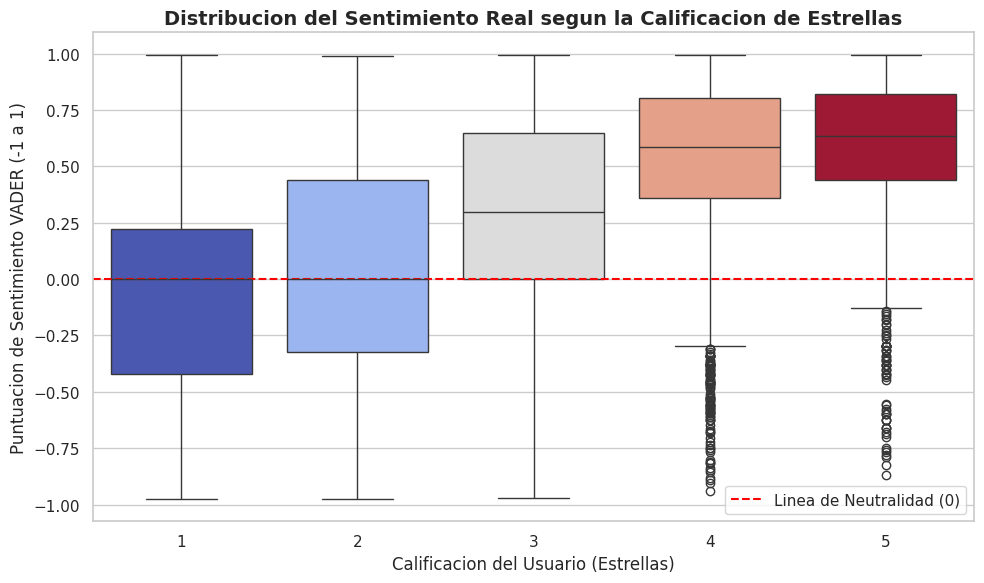

Grafica generada con exito.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando grafico de relacion: Estrellas vs Sentimiento Analitico...")

# 1. Configuracion del tamano y estilo del grafico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Crear un Boxplot (Diagrama de cajas)
# X = Las estrellas que dio el usuario (1 a 5)
# Y = La puntuacion de sentimiento de VADER (-1.0 a 1.0)
ax = sns.boxplot(x='score', y='vader_score', data=df, palette='coolwarm', hue='score', legend=False)

# 3. Anadir una linea horizontal en el 0 (Neutralidad)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Linea de Neutralidad (0)')

# 4. Formatear titulos y etiquetas para nivel corporativo
plt.title('Distribucion del Sentimiento Real segun la Calificacion de Estrellas', fontsize=14, fontweight='bold')
plt.xlabel('Calificacion del Usuario (Estrellas)', fontsize=12)
plt.ylabel('Puntuacion de Sentimiento VADER (-1 a 1)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

print("Grafica generada con exito.")

### Fase 4: Conclusiones y Valor Estratégico de Negocio

El pipeline de Procesamiento de Lenguaje Natural desarrollado en este notebook demuestra la capacidad de auditar de forma automatizada el impacto de las estrategias corporativas en la base de usuarios. Al transformar cientos de miles de reseñas en métricas cuantificables, se han identificado vulnerabilidades críticas en la experiencia del consumidor y en las métricas de evaluación tradicionales.

**Hallazgos Principales:**

1. **Fricción por Monetización y Lealtad:** La extracción de temas reveló que la mayor parte del descontento no proviene de usuarios nuevos, sino de la base leal que reciente transiciones hacia nuevos muros de pago ("waste money", "update app"). Esto subraya un riesgo de abandono (churn) alto ante cambios abruptos de monetización.
2. **La Ilusión del Promedio de Estrellas:** El análisis de disonancia cognitiva probó que depender exclusivamente del promedio de estrellas es un riesgo de negocio. Se detectaron valores atípicos significativos donde reseñas de 4 o 5 estrellas contienen un fuerte sentimiento analítico negativo, ocultando reportes de bugs o frustraciones bajo una calificación aparentemente buena.
3. **Identificación de Sarcasmo:** El modelo capturó varianzas extremas en las reseñas de 1 estrella, demostrando que algoritmos léxicos como VADER son efectivos para aislar quejas nostálgicas o sarcásticas ("used to love it") que modelos tradicionales pasarían por alto.

**Impacto del Proyecto:**
Este análisis prueba que es posible medir matemáticamente el descontento real frente a prácticas de diseño o políticas de precios. Proveer estos insights accionables permite a las corporaciones auditar la salud real de su software, trascendiendo las métricas superficiales para ajustar estrategias antes de sufrir daños irreversibles en la retención.